# KK1 – Spotify Songs: En dataanalys

**Kurs:** Artificiell Intelligens – programmering Python (MAI25MA)  
**Dataset:** Spotify Songs (TidyTuesday 2020-01-21)  

---

## 1. Inledning – kontext

Datasetet innehåller information om drygt 30 000 låtar hämtade via Spotifys API. Varje rad representerar en unik låt och inkluderar både metadata (artist, album, genre, utgivningsår) och ljudfunktioner som Spotify beräknar automatiskt – till exempel `danceability` (hur dansbart spåret är, 0–1), `energy` (intensitet och aktivitet, 0–1), `loudness` (genomsnittlig volym i decibel) och `popularity` (ett poäng 0–100 baserat på antal streams och hur nyligen de skedde).

**Varifrån kommer datan?** Datasetet publicerades av TidyTuesday (ett öppet dataprojekt) och är hämtat från Spotifys publika API via R-paketet `spotifyr`. Det speglar Spotifys egna kategoriseringar av låtar i sex spellistgenrer: EDM, Latin, Pop, R&B, Rap och Rock.

**Vad kan vi *inte* veta?** Datasetet täcker inte alla låtar på Spotify – urvalet är begränsat till låtar i vissa spellistor. Popularitetspoängen är en ögonblicksbild och förändras hela tiden. Vi kan alltså dra slutsatser om *dessa* låtar, men inte generalisera till all musik på Spotify.

**Mina frågor för analysen:**
1. Hur ser fördelningen av popularitet ut – är de flesta låtar populära eller opopulära?
2. Skiljer sig energinivån åt mellan genrer?
3. Finns det ett samband mellan danceability och energy?
4. Hur har låtarnas tempo förändrats över tid?

## 2. Inläsning och mekanisk inspektion

In [1]:
from io import StringIO

import certifi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import requests
import seaborn as sns

# Ladda ner datasetet direkt från TidyTuesday
url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-01-21/spotify_songs.csv"
response = requests.get(url, headers={"User-Agent": "Mozilla/5.0"}, verify=certifi.where(), timeout=30)
response.raise_for_status()
df = pd.read_csv(StringIO(response.text))

print("Inläsning klar.")
print(f"Storlek: {df.shape[0]} rader × {df.shape[1]} kolumner")

Inläsning klar.
Storlek: 32833 rader × 23 kolumner


In [2]:
# Övergripande struktur
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  str    
 1   track_name                32828 non-null  str    
 2   track_artist              32828 non-null  str    
 3   track_popularity          32833 non-null  int64  
 4   track_album_id            32833 non-null  str    
 5   track_album_name          32828 non-null  str    
 6   track_album_release_date  32833 non-null  str    
 7   playlist_name             32833 non-null  str    
 8   playlist_id               32833 non-null  str    
 9   playlist_genre            32833 non-null  str    
 10  playlist_subgenre         32833 non-null  str    
 11  danceability              32833 non-null  float64
 12  energy                    32833 non-null  float64
 13  key                       32833 non-null  int64  
 14  loudness         

In [3]:
# Statistisk sammanfattning av numeriska kolumner
df.describe().round(2)

,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
count,32833.00,32833.00,32833.00,32833.00,32833.00,32833.00,32833.00,32833.00,32833.00,32833.00,32833.00,32833.00,32833.00
mean,42.48,0.65,0.70,5.37,-6.72,0.57,0.11,0.18,0.08,0.19,0.51,120.88,225799.81
std,24.98,0.15,0.18,3.61,2.99,0.50,0.10,0.22,0.22,0.15,0.23,26.90,59834.01
min,0.00,0.00,0.00,0.00,-46.45,0.00,0.00,0.00,0.00,0.00,0.00,0.00,4000.00
25%,24.00,0.56,0.58,2.00,-8.17,0.00,0.04,0.02,0.00,0.09,0.33,99.96,187819.00
50%,45.00,0.67,0.72,6.00,-6.17,1.00,0.06,0.08,0.00,0.13,0.51,121.98,216000.00
75%,62.00,0.76,0.84,9.00,-4.64,1.00,0.13,0.26,0.00,0.25,0.69,133.92,253585.00
max,100.00,0.98,1.00,11.00,1.27,1.00,0.92,0.99,0.99,1.00,0.99,239.44,517810.00


In [4]:
# Kontrollera saknade värden
saknade = df.isnull().sum()
saknade[saknade > 0]

track_name          5
track_artist        5
track_album_name    5
dtype: int64

In [5]:
# Vilka genrer finns?
df['playlist_genre'].value_counts()

playlist_genre
edm      6043
rap      5746
pop      5507
r&b      5431
latin    5155
rock     4951
Name: count, dtype: int64

**Observationer från inspektionen:**
- Datasetet har 32 833 rader och 23 kolumner.
- Det finns ett litet antal saknade värden i `track_name`, `track_artist` och `track_album_name` – dessa rader saknar alltså grundläggande metadata.
- Numeriska kolumner som `danceability`, `energy`, `speechiness` m.fl. ligger alla inom rimliga intervall (0–1 eller liknande).
- Sex genrer finns representerade: edm, latin, pop, r&b, rap, rock – relativt jämnt fördelade.

## 3. Datatvätt

Jag gör tre medvetna åtgärder:

In [6]:
print(f"Rader innan tvätt: {len(df)}")

# --- Åtgärd 1: Ta bort rader där track_name eller track_artist saknas ---
# Motivering: En låt utan namn eller artist är oanvändbar för analys och
# troligen ett datainsamlingsfel, inte ett meningsfullt saknat värde.
df = df.dropna(subset=['track_name', 'track_artist'])
print(f"Efter att tagit bort rader utan låtnamn/artist: {len(df)}")

# --- Åtgärd 2: Ta bort exakta dubbletter (samma track_id) ---
# Motivering: Samma låt kan förekomma i flera spellistor och ge samma
# track_id. Om jag räknar statistik per låt vill jag inte räkna samma
# låt dubbelt. Jag behåller första förekomsten.
df = df.drop_duplicates(subset='track_id', keep='first')
print(f"Efter att tagit bort dubbletter på track_id: {len(df)}")

# --- Åtgärd 3: Extrahera utgivningsår från track_album_release_date ---
# Motivering: Datumkolumnen är en sträng i varierande format (YYYY, YYYY-MM,
# YYYY-MM-DD). Jag extraherar enbart årtalet för att kunna analysera
# tidstrender utan att behöva hantera alla datumformat.
df['release_year'] = pd.to_numeric(
    df['track_album_release_date'].str[:4], errors='coerce'
)
print(f"Årtalskolumn skapad. Saknade år: {df['release_year'].isnull().sum()}")

Rader innan tvätt: 32833
Efter att tagit bort rader utan låtnamn/artist: 32828
Efter att tagit bort dubbletter på track_id: 28352
Årtalskolumn skapad. Saknade år: 0


In [7]:
# Kontrollera resultatet
print(f"\nSlutlig storlek: {df.shape[0]} rader × {df.shape[1]} kolumner")
df[['track_name', 'track_artist', 'playlist_genre', 'release_year', 
    'danceability', 'energy', 'tempo', 'track_popularity']].head()


Slutlig storlek: 28352 rader × 24 kolumner


,track_name,track_artist,playlist_genre,release_year,danceability,energy,tempo,track_popularity
0,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,pop,2019,0.748,0.916,122.036,66
1,Memories - Dillon Francis Remix,Maroon 5,pop,2019,0.726,0.815,99.972,67
2,All the Time - Don Diablo Remix,Zara Larsson,pop,2019,0.675,0.931,124.008,70
3,Call You Mine - Keanu Silva Remix,The Chainsmokers,pop,2019,0.718,0.930,121.956,60
4,Someone You Loved - Future Humans Remix,Lewis Capaldi,pop,2019,0.650,0.833,123.976,69


## 4. Utforskning genom visualisering

---

### Visualisering 1: Hur populära är låtarna egentligen?

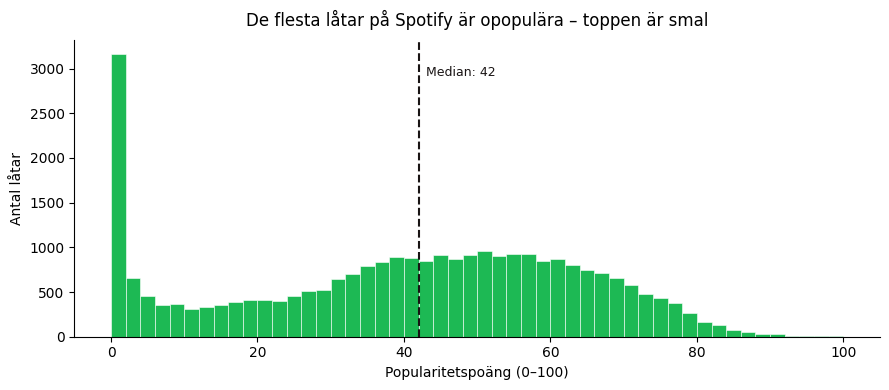

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(df['track_popularity'], bins=50, color='#1DB954', edgecolor='white', linewidth=0.4)

# Markera medianen
median_pop = df['track_popularity'].median()
ax.axvline(median_pop, color='#191414', linewidth=1.5, linestyle='--')
ax.text(median_pop + 1, ax.get_ylim()[1] * 0.88,
        f'Median: {median_pop:.0f}', color='#191414', fontsize=9)

ax.set_title('De flesta låtar på Spotify är opopulära – toppen är smal', fontsize=12, pad=10)
ax.set_xlabel('Popularitetspoäng (0–100)', fontsize=10)
ax.set_ylabel('Antal låtar', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('viz1_popularitet.png', dpi=150, bbox_inches='tight')
plt.show()

**Vad bilden visar:** Fördelningen är kraftigt högersnedvriden med en stor topp vid noll. Det betyder att majoriteten av låtarna i datasetet i princip inte streamas alls – medianen ligger runt 45 och poäng över 80 är sällsynta. Det är intressant eftersom det bekräftar att Spotify-ekosystemet domineras av ett fåtal mycket populära låtar medan långsvansen av opopulärt innehåll är enorm.

---

### Visualisering 2: Skiljer sig energinivån åt mellan genrer?

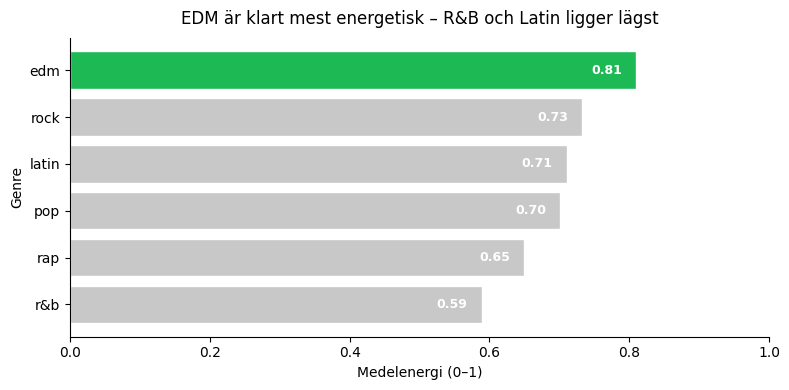

In [9]:
# Beräkna medel-energy per genre, sorterat
genre_energy = (
    df.groupby('playlist_genre')['energy']
    .mean()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(8, 4))

colors = ['#1DB954' if g == genre_energy.idxmax() else '#C8C8C8' for g in genre_energy.index]
bars = ax.barh(genre_energy.index, genre_energy.values, color=colors, edgecolor='white')

# Lägg till värden i staplarna
for bar, val in zip(bars, genre_energy.values):
    ax.text(val - 0.02, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center', ha='right', color='white', fontsize=9, fontweight='bold')

ax.set_xlim(0, 1)
ax.set_title('EDM är klart mest energetisk – R&B och Latin ligger lägst', fontsize=12, pad=10)
ax.set_xlabel('Medelenergi (0–1)', fontsize=10)
ax.set_ylabel('Genre', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('viz2_energy_genre.png', dpi=150, bbox_inches='tight')
plt.show()

**Vad bilden visar:** EDM har tydligt högst medelenergi (runt 0.80) vilket är väntat för elektronisk dansmusik. R&B och Latin ligger lägst. Stapeldiagram valdes eftersom jag jämför ett mätvärde (medelenergi) för sex kategorier – det är en klassisk jämförelseuppgift där horisontella staplar gör genrenamnen läsbara.

---

### Visualisering 3: Finns det ett samband mellan dansbarhet och energi?

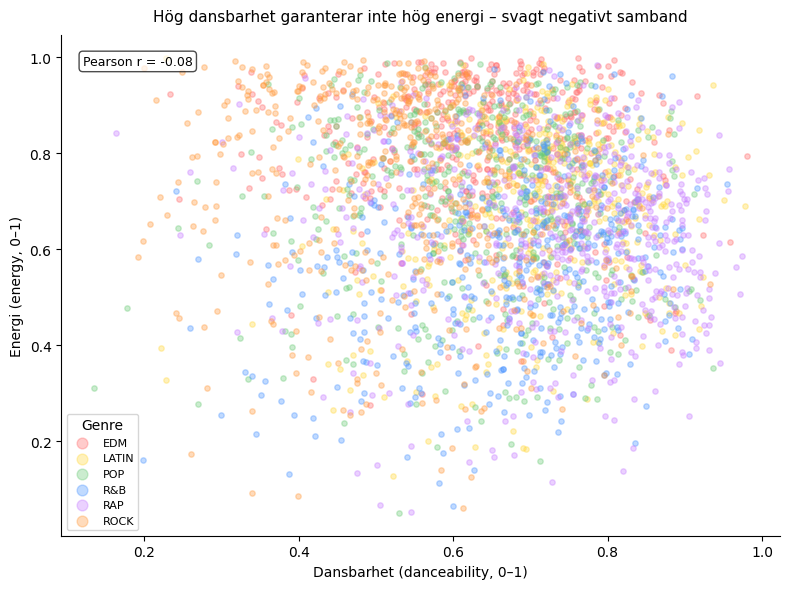

In [10]:
# Sampla för att undvika överplotting (32k punkter blir oläsligt)
sample = df.sample(n=3000, random_state=42)

# Färgkarta per genre
genre_colors = {
    'edm': '#FF6B6B', 'latin': '#FFD93D', 'pop': '#6BCB77',
    'r&b': '#4D96FF', 'rap': '#C77DFF', 'rock': '#FF9A3C'
}

fig, ax = plt.subplots(figsize=(8, 6))

for genre, grp in sample.groupby('playlist_genre'):
    ax.scatter(
        grp['danceability'], grp['energy'],
        color=genre_colors.get(genre, 'gray'),
        alpha=0.35, s=15, label=genre.upper()
    )

# Korrelation
corr = df['danceability'].corr(df['energy'])
ax.text(0.03, 0.96, f'Pearson r = {corr:.2f}',
        transform=ax.transAxes, fontsize=9, va='top',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

ax.set_title('Hög dansbarhet garanterar inte hög energi – svagt negativt samband', fontsize=11, pad=10)
ax.set_xlabel('Dansbarhet (danceability, 0–1)', fontsize=10)
ax.set_ylabel('Energi (energy, 0–1)', fontsize=10)
ax.legend(title='Genre', fontsize=8, markerscale=2, loc='lower left')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('viz3_dance_energy.png', dpi=150, bbox_inches='tight')
plt.show()

**Vad bilden visar:** Det svaga negativa Pearson-korrelationsvärdet (runt -0.1) är överraskande – man kanske förväntar sig att dansmusik är energetisk, men det stämmer inte i dessa data. EDM (röd) tenderar att ha hög energi men varierad dansbarhet, medan R&B (blå) klustrar i hög dansbarhet och lägre energi. Spridningsdiagrammet valdes eftersom frågan handlar om ett *samband* mellan två kontinuerliga variabler.

---

### Visualisering 4: Har låtarnas tempo förändrats sedan 1990?

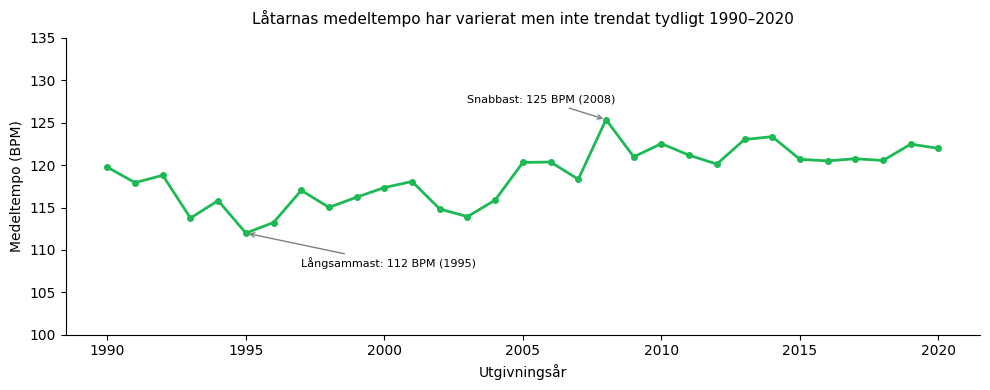

In [11]:
# Filtrera till 1990-2020 och beräkna medeltempo per år
tempo_per_ar = (
    df[(df['release_year'] >= 1990) & (df['release_year'] <= 2020)]
    .groupby('release_year')['tempo']
    .agg(['mean', 'count'])
    .reset_index()
)

# Filtrera bort år med för få låtar (< 30) – de ger opålitliga medelvärden
tempo_per_ar = tempo_per_ar[tempo_per_ar['count'] >= 30]

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(tempo_per_ar['release_year'], tempo_per_ar['mean'],
        color='#1DB954', linewidth=2, marker='o', markersize=4)

# Markera min och max
max_row = tempo_per_ar.loc[tempo_per_ar['mean'].idxmax()]
min_row = tempo_per_ar.loc[tempo_per_ar['mean'].idxmin()]

ax.annotate(f"Snabbast: {max_row['mean']:.0f} BPM ({int(max_row['release_year'])})",
            xy=(max_row['release_year'], max_row['mean']),
            xytext=(max_row['release_year'] - 5, max_row['mean'] + 2),
            fontsize=8, arrowprops=dict(arrowstyle='->', color='gray'))

ax.annotate(f"Långsammast: {min_row['mean']:.0f} BPM ({int(min_row['release_year'])})",
            xy=(min_row['release_year'], min_row['mean']),
            xytext=(min_row['release_year'] + 2, min_row['mean'] - 4),
            fontsize=8, arrowprops=dict(arrowstyle='->', color='gray'))

ax.set_title('Låtarnas medeltempo har varierat men inte trendat tydligt 1990–2020', fontsize=11, pad=10)
ax.set_xlabel('Utgivningsår', fontsize=10)
ax.set_ylabel('Medeltempo (BPM)', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.set_ylim(100, 135)

plt.tight_layout()
plt.savefig('viz4_tempo_tid.png', dpi=150, bbox_inches='tight')
plt.show()

**Vad bilden visar:** Medeltempot fluktuerar inom ett relativt smalt band (ca 115–130 BPM) utan en tydlig stigande eller sjunkande trend. Det är intressant eftersom medierapporter ofta hävdar att musik blivit snabbare – dessa data ger inget stöd för det påståendet, åtminstone inte inom det här urvalet av spellistlåtar. Linjediagram valdes eftersom frågan handlar om förändring *över tid* – det är en tidsserie, och linjen visar kontinuiteten.

---

## 5. Avslutning – vad jag lärt mig och vad jag inte kan veta

### Mönster jag hittade

**Popularitet är extremt ojämnt fördelad.** Stora delar av datasetet har noll eller nära-noll popularitet. Det är inte ett datafel – det speglar verklighetens "winner-take-all"-dynamik på streamingplattformar.

**Genre påverkar energi tydligt, men inte dansbarhet på förväntat sätt.** EDM är energetisk, men hög dansbarhet hittas i R&B och Latin – genrer med lägre energi. Det utmanar intuitionen att "dansmusik = hög energi".

**Tempot är stabilt.** Ingen tydlig trend i BPM 1990–2020. Populärvetenskapliga påståenden om att musik blivit snabbare stöds inte av dessa data.

### Vad datan inte kan berätta

- **Urvalsbias:** Datasetet täcker bara låtar i vissa Spotify-spellistor. Det finns miljontals låtar på Spotify som aldrig hamnar i en spellista och därför inte är representerade.
- **Popularitet är en ögonblicksbild.** En låt som var populär 2018 kan ha låg poäng idag. Tidsjämförelser av popularitet är därför problematiska.
- **Kausalitet:** Vi kan se att EDM har hög energy, men vi vet inte *varför*. Är det för att producenter medvetet optimerar det, eller är det ett genremarkeringssystem Spotify tränat?
- **Geografisk representation:** Det är oklart hur väl icke-engelskspråkig musik representeras, trots att Latin är en kategori.